<a href="https://colab.research.google.com/github/BhawookPriyam/Network-Anomaly-Detection-Using-ML/blob/main/Network_Anomaly_Detection_Using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 📦 IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix


# Set a clean visualization style
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
# ============================================================
# 📂 LOAD THE NETWORK TRAFFIC DATASET
# ============================================================

# Load the CSV file
# Try several common dataset locations so the notebook works on Colab,
# local Jupyter, or any similar environment.
candidate_paths = [
    "/content/Data/network_traffic.csv",
    "/content/network_traffic.csv",
    os.path.join(os.getcwd(), "Data", "network_traffic.csv"),
    os.path.join(os.getcwd(), "network_traffic.csv"),
    "./Data/network_traffic.csv",
    "./network_traffic.csv",
]

for path in candidate_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break
else:
    raise FileNotFoundError(
        "Dataset not found. Please upload 'network_traffic.csv' to the notebook "
        "environment or update the path. Tried: " + ", ".join(candidate_paths)
    )

# Different network-traffic exports (different CICFlowMeter versions,
# other capture tools, other data sources) are inconsistent about
# leading/trailing spaces in column names -- e.g. " Label" in one file
# and "Label" in another. Standardizing this once, right after
# loading, means every cell below works the same way no matter which
# export produced the CSV.
df.columns = df.columns.str.strip()

print("✅ Dataset loaded successfully!")
print(f"📊 Columns detected: {df.shape[1]}")


✅ Dataset loaded successfully!
📊 Columns detected: 79


In [6]:
# ============================================================
# 🔍 EXPLORE THE DATASET
# ============================================================

# Display the first 5 rows
print("📋 First 5 rows of the dataset:")
display(df.head())

# Check the number of rows and columns
print(f"📊 Number of Rows    : {df.shape[0]:,}")
print(f"📊 Number of Columns : {df.shape[1]:,}")

# Display all column names
print("📌 Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

📋 First 5 rows of the dataset:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


📊 Number of Rows    : 170,366
📊 Number of Columns : 79
📌 Dataset Columns:

 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Max
 8. Fwd Packet Length Min
 9. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Bwd PSH Flags
33. Fwd URG Flags
34. Bwd URG Flags
35. Fwd Header Length
36. Bwd Header Length
37. Fwd Packets/s
38. Bwd Packets/s
39. Min Packet Length
40. Max Packet Length
41. Packet Length Mean
42. Packet Length Std
43. Packet Length Variance
44. FIN Flag Count
45. S

In [7]:
# ============================================================
# 🧾 DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170366 entries, 0 to 170365
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             170366 non-null  int64  
 1   Flow Duration                170366 non-null  int64  
 2   Total Fwd Packets            170366 non-null  int64  
 3   Total Backward Packets       170366 non-null  int64  
 4   Total Length of Fwd Packets  170366 non-null  int64  
 5   Total Length of Bwd Packets  170366 non-null  int64  
 6   Fwd Packet Length Max        170366 non-null  int64  
 7   Fwd Packet Length Min        170366 non-null  int64  
 8   Fwd Packet Length Mean       170366 non-null  float64
 9   Fwd Packet Length Std        170366 non-null  float64
 10  Bwd Packet Length Max        170366 non-null  int64  
 11  Bwd Packet Length Min        170366 non-null  int64  
 12  Bwd Packet Length Mean       170366 non-null  float64
 13  Bwd Packet

Distribution of network traffic labels:

Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64


C:\Users\bhawo\AppData\Local\Temp\ipykernel_27344\3987914885.py:23: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bhawo\AppData\Local\Temp\ipykernel_27344\3987914885.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bhawo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bhawo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


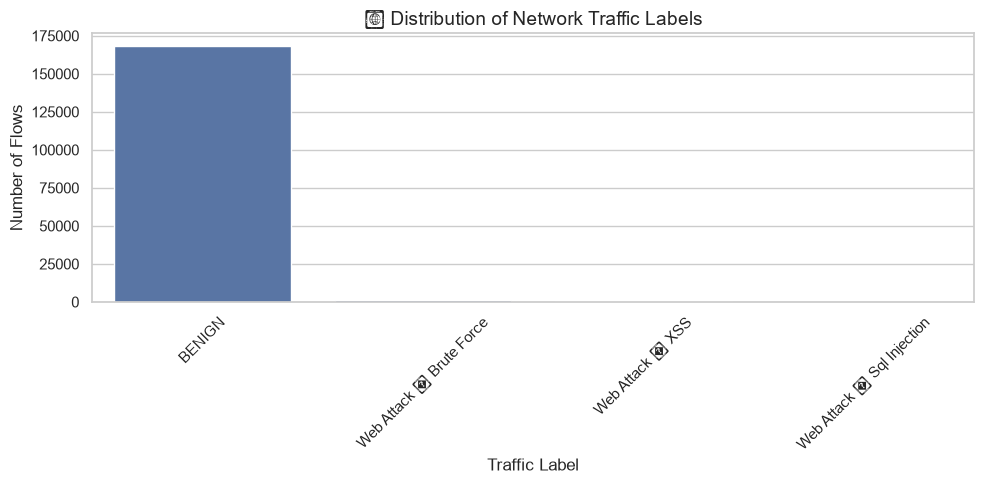

In [8]:
# ============================================================
# 🏷️ UNDERSTAND THE NETWORK TRAFFIC LABELS
# ============================================================

print("Distribution of network traffic labels:\n")

print(df["Label"].value_counts())

# Visualize the label distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    x=df["Label"],
    order=df["Label"].value_counts().index
)

plt.title("📊 Distribution of Network Traffic Labels", fontsize=14)
plt.xlabel("Traffic Label")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [9]:
# ============================================================
# 🧹 DATA CLEANING
# ============================================================

# ------------------------------------------------------------
# Step 1: Remove duplicate records
# ------------------------------------------------------------

initial_rows = len(df)

df = df.drop_duplicates()

removed_duplicates = initial_rows - len(df)

print(f"🗑️ Duplicate records removed: {removed_duplicates:,}")
print(f"📊 Remaining rows: {len(df):,}")

# ------------------------------------------------------------
# Step 2: Replace infinite values with NaN
# ------------------------------------------------------------

df = df.replace([np.inf, -np.inf], np.nan)

print("✅ Infinite values replaced with NaN.")

# ------------------------------------------------------------
# Step 3: Check for missing values
# ------------------------------------------------------------

print("🔎 Missing values in each column:\n")

missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
)

# ------------------------------------------------------------
# Step 4: Remove rows containing missing values
# ------------------------------------------------------------

before_dropna = len(df)

df = df.dropna()

removed_missing = before_dropna - len(df)

print(f"🗑️ Rows removed because of missing values: {removed_missing:,}")
print(f"📊 Final dataset shape: {df.shape}")

🗑️ Duplicate records removed: 6,066
📊 Remaining rows: 164,300
✅ Infinite values replaced with NaN.
🔎 Missing values in each column:



Flow Bytes/s      121
Flow Packets/s    121
dtype: int64

🗑️ Rows removed because of missing values: 121
📊 Final dataset shape: (164179, 79)


In [10]:
# ============================================================
# 🎯 SEPARATE LABELS FROM FEATURES
# ============================================================

# Store the actual network traffic labels
labels = df["Label"].copy()

# Remove the label column from the feature dataset
x_processed_features = df.drop(columns=["Label"])

print(f"🏷️ Labels shape   : {labels.shape}")
print(f"📊 Features shape : {x_processed_features.shape}")


🏷️ Labels shape   : (164179,)
📊 Features shape : (164179, 78)


In [11]:
# ============================================================
# 🧹 REMOVE UNSUITABLE / IDENTIFYING COLUMNS
# ============================================================

# These columns are not directly used by our model.
# They identify a connection rather than describing its
# numerical network behavior. A couple of alternate spellings are
# included so this still works on exports from other tools/sources.

columns_to_remove = [
    "Flow ID",
    "Source IP", "Src IP",
    "Destination IP", "Dst IP",
    "Timestamp"
]

for column in columns_to_remove:

    if column in x_processed_features.columns:
        x_processed_features = x_processed_features.drop(
            columns=[column]
        )

print("✅ Unwanted columns removed.")
print(f"📊 Remaining columns: {x_processed_features.shape[1]}")


✅ Unwanted columns removed.
📊 Remaining columns: 78


In [12]:
# ============================================================
# 🔢 CONVERT FEATURES INTO NUMERIC FORMAT
# ============================================================

# Convert categorical columns into numerical dummy variables
x_processed_features = pd.get_dummies(
    x_processed_features
)

# Display data types
print("📊 Data types after encoding:\n")
print(
    x_processed_features.dtypes.value_counts()
)

# Convert all values to numeric
x_processed_features = x_processed_features.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace infinite values
# (Flow Bytes/s and Flow Packets/s divide by Flow Duration, which can
#  be 0 for very short flows -- this produces +/- infinity more often
#  in some network-traffic exports than others.)
x_processed_features = x_processed_features.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows containing NaN values
x_processed_features = x_processed_features.dropna()

# ⚠️ IMPORTANT FIX: the cleaning above can drop rows. `labels` was
# captured before this cleaning, so without the line below it would
# no longer line up row-for-row with `x_processed_features` -- every
# metric computed later (classification report, confusion matrix)
# would silently be comparing predictions to the wrong ground-truth
# labels. This mismatch gets worse the more cleaning a dataset needs,
# which is exactly what tends to happen with data from another source.
labels = labels.loc[x_processed_features.index]

print("✅ Features converted to numeric format.")
print(f"📊 Processed feature shape: {x_processed_features.shape}")
print(f"🏷️ Realigned labels shape : {labels.shape}")


📊 Data types after encoding:

int64      54
float64    24
Name: count, dtype: int64
✅ Features converted to numeric format.
📊 Processed feature shape: (164179, 78)
🏷️ Realigned labels shape : (164179,)


In [13]:
# ============================================================
# 🎯 SELECT & ENGINEER ROBUST NETWORK TRAFFIC FEATURES
# ============================================================
#
# The original 9 features were raw magnitudes -- packet counts, byte
# counts, flow duration. Those scale directly with how long a capture
# ran and how "big" its traffic was, so a value that is normal in one
# dataset can look extreme in another, and vice versa. That mismatch
# is the main reason results did not carry over to data from another
# source.
#
# The features below are RATES and RATIOS instead -- they describe
# HOW a flow behaves (its shape, timing, symmetry) rather than HOW
# BIG it is, so they compare much more consistently across datasets.
# Column names are also resolved through common aliases, since
# different capture tools / CICFlowMeter versions spell them
# differently (e.g. "Total Fwd Packets" vs "Tot Fwd Pkts").

def get_col(frame, *candidates):
    """Return the actual column name matching any of the given
    aliases (whitespace/case-insensitive), or None if not present."""
    lookup = {c.strip().lower(): c for c in frame.columns}
    for name in candidates:
        match = lookup.get(name.strip().lower())
        if match is not None:
            return match
    return None


def build_feature_matrix(frame):
    """Build the engineered feature matrix from a cleaned, numeric
    flow-feature dataframe. Used for both training (below) and for
    scoring new/unseen data later, so both go through identical logic."""

    col = {
        "duration":      get_col(frame, "Flow Duration"),
        "fwd_pkts":      get_col(frame, "Total Fwd Packets", "Tot Fwd Pkts"),
        "bwd_pkts":      get_col(frame, "Total Backward Packets", "Tot Bwd Pkts"),
        "fwd_bytes":     get_col(frame, "Total Length of Fwd Packets", "TotLen Fwd Pkts"),
        "bwd_bytes":     get_col(frame, "Total Length of Bwd Packets", "TotLen Bwd Pkts"),
        "fwd_len_mean":  get_col(frame, "Fwd Packet Length Mean", "Fwd Pkt Len Mean"),
        "fwd_len_std":   get_col(frame, "Fwd Packet Length Std", "Fwd Pkt Len Std"),
        "bwd_len_mean":  get_col(frame, "Bwd Packet Length Mean", "Bwd Pkt Len Mean"),
        "bwd_len_std":   get_col(frame, "Bwd Packet Length Std", "Bwd Pkt Len Std"),
        "flow_iat_mean": get_col(frame, "Flow IAT Mean"),
        "flow_iat_std":  get_col(frame, "Flow IAT Std"),
        "fwd_iat_mean":  get_col(frame, "Fwd IAT Mean"),
        "bwd_iat_mean":  get_col(frame, "Bwd IAT Mean"),
        "syn":           get_col(frame, "SYN Flag Count", "SYN Flag Cnt"),
        "rst":           get_col(frame, "RST Flag Count", "RST Flag Cnt"),
        "fin":           get_col(frame, "FIN Flag Count", "FIN Flag Cnt"),
        "psh":           get_col(frame, "PSH Flag Count", "PSH Flag Cnt"),
        "ack":           get_col(frame, "ACK Flag Count", "ACK Flag Cnt"),
        "init_win_fwd":  get_col(frame, "Init_Win_bytes_forward", "Init Fwd Win Byts"),
        "init_win_bwd":  get_col(frame, "Init_Win_bytes_backward", "Init Bwd Win Byts"),
    }

    missing = [k for k, v in col.items() if v is None]
    if missing:
        print(f"ℹ️ Source columns not found for: {missing} -- related features will be skipped.")

    out = pd.DataFrame(index=frame.index)

    # Flow Duration is in microseconds in CICIDS-style exports.
    duration_sec = frame[col["duration"]].clip(lower=1) / 1_000_000 if col["duration"] else None
    total_pkts = None
    total_bytes = None

    if col["fwd_pkts"] and col["bwd_pkts"]:
        total_pkts = frame[col["fwd_pkts"]] + frame[col["bwd_pkts"]]
        # Flow symmetry: scans/floods tend to be very one-sided.
        out["fwd_bwd_pkt_ratio"] = frame[col["fwd_pkts"]] / frame[col["bwd_pkts"]].clip(lower=1)

    if col["fwd_bytes"] and col["bwd_bytes"]:
        total_bytes = frame[col["fwd_bytes"]] + frame[col["bwd_bytes"]]
        out["fwd_bwd_byte_ratio"] = frame[col["fwd_bytes"]] / frame[col["bwd_bytes"]].clip(lower=1)

    # Rates (already scale-independent: units per second). log1p keeps
    # a handful of extreme flows from dominating the scaling step later.
    if duration_sec is not None and total_pkts is not None:
        out["pkts_per_sec"] = np.log1p(total_pkts / duration_sec)

    if duration_sec is not None and total_bytes is not None:
        out["bytes_per_sec"] = np.log1p(total_bytes / duration_sec)

    if total_bytes is not None and total_pkts is not None:
        out["avg_pkt_size"] = total_bytes / total_pkts.clip(lower=1)

    for key in ["fwd_len_mean", "fwd_len_std", "bwd_len_mean", "bwd_len_std"]:
        if col[key]:
            out[key] = frame[col[key]]

    # Timing pattern between packets -- very regular timing tends to
    # look bot-/scan-like regardless of how big the dataset itself is.
    if col["flow_iat_mean"]:
        out["flow_iat_mean"] = np.log1p(frame[col["flow_iat_mean"]].clip(lower=0))
    if col["flow_iat_std"]:
        out["flow_iat_std"] = np.log1p(frame[col["flow_iat_std"]].clip(lower=0))
    if col["fwd_iat_mean"]:
        out["fwd_iat_mean"] = np.log1p(frame[col["fwd_iat_mean"]].clip(lower=0))
    if col["bwd_iat_mean"]:
        out["bwd_iat_mean"] = np.log1p(frame[col["bwd_iat_mean"]].clip(lower=0))

    # Flag ratios (normalized by packet count) capture protocol-level
    # behavior -- e.g. a flood of SYNs with almost no ACK/FIN -- without
    # depending on how long or large the flow happened to be.
    if total_pkts is not None:
        pkt_denom = total_pkts.clip(lower=1)
        for key in ["syn", "rst", "fin", "psh", "ack"]:
            if col[key]:
                out[f"{key}_ratio"] = frame[col[key]] / pkt_denom

    for key in ["init_win_fwd", "init_win_bwd"]:
        if col[key]:
            out[key] = frame[col[key]]

    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
    return out


X = build_feature_matrix(x_processed_features)
FEATURE_COLUMNS = X.columns.tolist()

print("✅ Engineered features:\n")
for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i}. {feature}")

print(f"\n📊 Final feature matrix shape: {X.shape}")


✅ Engineered features:

1. fwd_bwd_pkt_ratio
2. fwd_bwd_byte_ratio
3. pkts_per_sec
4. bytes_per_sec
5. avg_pkt_size
6. fwd_len_mean
7. fwd_len_std
8. bwd_len_mean
9. bwd_len_std
10. flow_iat_mean
11. flow_iat_std
12. fwd_iat_mean
13. bwd_iat_mean
14. syn_ratio
15. rst_ratio
16. fin_ratio
17. psh_ratio
18. ack_ratio
19. init_win_fwd
20. init_win_bwd

📊 Final feature matrix shape: (164179, 20)


In [14]:
# ============================================================
# ⚖️ FEATURE SCALING
# ============================================================

# RobustScaler centers on the median and scales by the interquartile
# range instead of the mean/standard deviation. Network flow data is
# naturally heavy-tailed (a handful of very large flows), and those
# extreme values can dominate a mean/std-based scale -- RobustScaler
# is much less thrown off by them, which helps the same scaling logic
# hold up on traffic from a different source.

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Feature scaling completed!")
print(f"📊 Scaled data shape: {X_scaled.shape}")


✅ Feature scaling completed!
📊 Scaled data shape: (164179, 20)


In [15]:
# ============================================================
# 🌲 TRAIN ISOLATION FOREST
# ============================================================

# contamination="auto" lets Isolation Forest set its own decision
# threshold (per the original Liu et al. paper) instead of forcing
# exactly 5% of every dataset to be flagged anomalous -- that fixed
# 5% assumption is a big part of why results looked wrong on data with
# a different true anomaly rate. Only set this to a number if you
# actually know the expected anomaly rate for THIS specific data.
CONTAMINATION = "auto"

model = IsolationForest(
    n_estimators=200,       # more trees -> more stable anomaly scores
    max_samples=256,        # paper-recommended sample size; keeps the
                            # model from calibrating "normal" around
                            # one dataset's particular scale
    max_features=0.8,       # each tree sees a random subset of
                            # features, reducing overfitting to any
                            # one engineered feature or correlation
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_scaled)

print("✅ Isolation Forest model trained successfully!")
print(f"🔧 contamination = {CONTAMINATION}, n_estimators = 200, max_samples = 256, max_features = 0.8")


✅ Isolation Forest model trained successfully!
🔧 contamination = auto, n_estimators = 200, max_samples = 256, max_features = 0.8


In [16]:
# ============================================================
# 🔍 GENERATE ANOMALY PREDICTIONS
# ============================================================

# Isolation Forest returns:
#   1  → Normal
#  -1  → Anomaly

predictions = model.predict(X_scaled)

# Convert numerical predictions into readable labels
result = np.where(
    predictions == -1,
    "Anomaly",
    "Normal"
)

# Display the first 20 predictions
print("🔎 First 20 predictions:\n")
print(result[:20])

🔎 First 20 predictions:

['Normal' 'Normal' 'Anomaly' 'Anomaly' 'Normal' 'Normal' 'Normal'
 'Anomaly' 'Normal' 'Normal' 'Normal' 'Anomaly' 'Anomaly' 'Normal'
 'Anomaly' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal']


In [17]:
# ============================================================
# 📈 CALCULATE ANOMALY SCORES
# ============================================================

# Lower scores indicate observations that are more unusual.

scores = model.decision_function(X_scaled)

# Create a DataFrame containing the results
results = pd.DataFrame({
    "Actual": labels,
    "Prediction": result,
    "Anomaly_Score": scores
})

print("📋 Sample prediction results:\n")

display(results.head(10))

📋 Sample prediction results:



,Actual,Prediction,Anomaly_Score
0,BENIGN,Normal,0.000962
1,BENIGN,Normal,0.023181
2,BENIGN,Anomaly,-0.017381
3,BENIGN,Anomaly,-0.004452
4,BENIGN,Normal,0.123854
5,BENIGN,Normal,0.138199
6,BENIGN,Normal,0.113097
7,BENIGN,Anomaly,-0.085613
8,BENIGN,Normal,0.140712
9,BENIGN,Normal,0.138801


In [18]:
# ============================================================
# 🏷️ CONVERT ACTUAL LABELS INTO NORMAL / ANOMALY
# ============================================================

# BENIGN traffic is considered Normal.
# All other labels are considered Anomaly.

actual = np.where(
    labels == "BENIGN",
    "Normal",
    "Anomaly"
)

# Convert labels into binary format:
# 0 → Normal
# 1 → Anomaly

y_true = np.where(
    labels == "BENIGN",
    0,
    1
)

# Convert model predictions into binary format:
# 0 → Normal
# 1 → Anomaly

y_pred = np.where(
    predictions == 1,
    0,
    1
)

print("✅ Actual and predicted labels prepared.")

✅ Actual and predicted labels prepared.


In [19]:
# ============================================================
# 📊 MODEL EVALUATION
# ============================================================

print("📊 Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Anomaly"]
    )
)

📊 Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.86      0.92    162036
     Anomaly       0.07      0.86      0.13      2143

    accuracy                           0.86    164179
   macro avg       0.54      0.86      0.53    164179
weighted avg       0.99      0.86      0.91    164179



C:\Users\bhawo\AppData\Local\Temp\ipykernel_27344\1078759598.py:25: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bhawo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


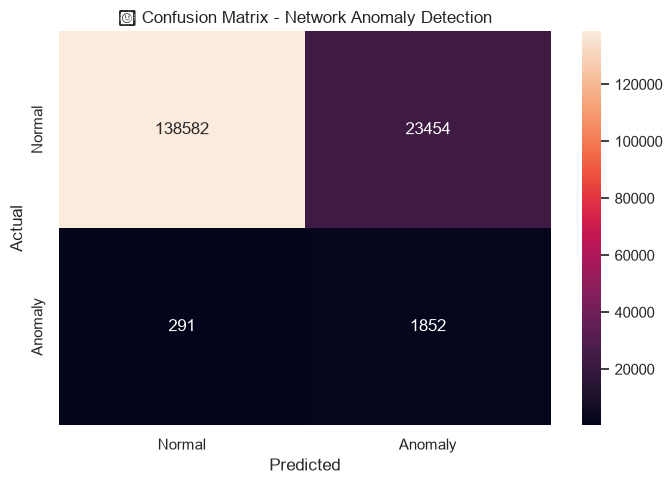

In [20]:
# ============================================================
# 🧩 CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("🧩 Confusion Matrix - Network Anomaly Detection")

plt.tight_layout()
plt.show()

C:\Users\bhawo\AppData\Local\Temp\ipykernel_27344\1696701015.py:20: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bhawo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


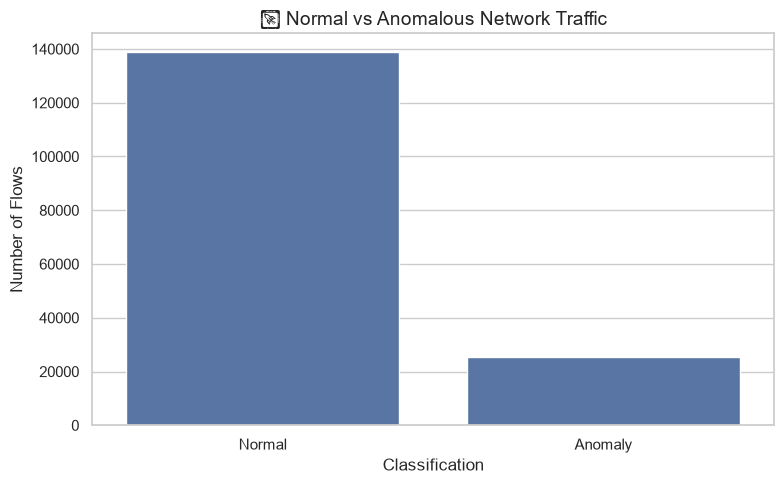

In [21]:
# ============================================================
# 📊 NORMAL VS ANOMALOUS NETWORK TRAFFIC
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=result,
    order=["Normal", "Anomaly"]
)

plt.title(
    "🚨 Normal vs Anomalous Network Traffic",
    fontsize=14
)

plt.xlabel("Classification")
plt.ylabel("Number of Flows")

plt.tight_layout()
plt.show()

C:\Users\bhawo\AppData\Local\Temp\ipykernel_27344\3585007537.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bhawo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


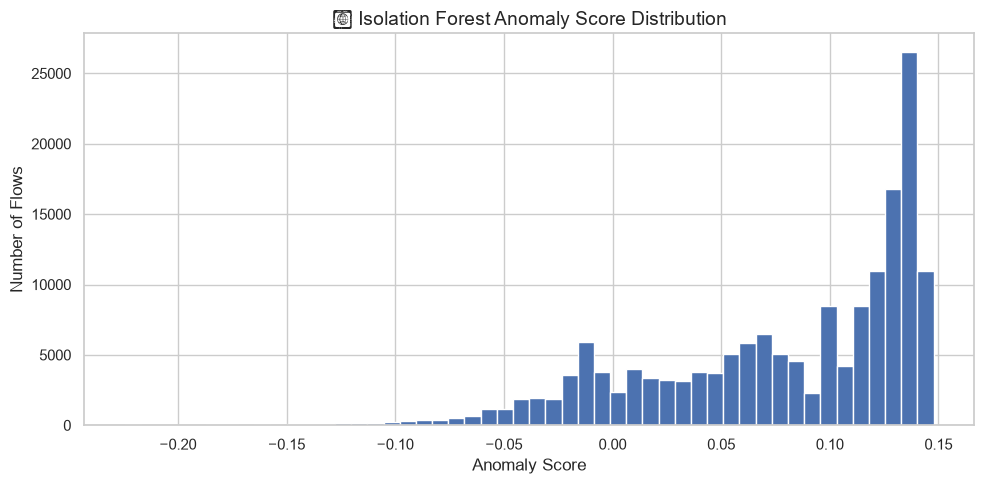

In [22]:
# ============================================================
# 📈 VISUALIZE ISOLATION FOREST ANOMALY SCORES
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    scores,
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flows")

plt.title(
    "📈 Isolation Forest Anomaly Score Distribution",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 💾 SAVE TRAINED MODEL AND SCALER
# ============================================================

# Create the model directory if it does not already exist
os.makedirs(
    "model",
    exist_ok=True
)

# Save the trained Isolation Forest model
joblib.dump(
    model,
    "model/isolation_forest.pkl"
)

# Save the scaler
joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("✅ Model saved successfully!")
print("📁 model/isolation_forest.pkl")

print("\n✅ Scaler saved successfully!")
print("📁 model/scaler.pkl")

✅ Model saved successfully!
📁 model/isolation_forest.pkl

✅ Scaler saved successfully!
📁 model/scaler.pkl


In [24]:
# ============================================================
# 🔎 VERIFY SAVED MODEL FILES
# ============================================================

print("📁 Saved model files:\n")

for file in os.listdir("model"):
    print(f"   ✅ {file}")

📁 Saved model files:

   ✅ isolation_forest.pkl
   ✅ scaler.pkl


In [25]:
# ============================================================
# 🔁 SCORE NEW / UNSEEN NETWORK TRAFFIC (A DIFFERENT DATA SOURCE)
# ============================================================
#
# The single most common reason results look wrong on a new data
# source is re-fitting the scaler/model on it. Fitting recalibrates
# "normal" to whatever happens to be in that specific file, so the
# exact same traffic can be scored completely differently depending
# on what else is in the batch.
#
# For genuinely new data, reuse the scaler and model already fit on
# the training set above, and only call .transform() / .predict() --
# never .fit_transform() or .fit() again.

def score_new_traffic(csv_path, scaler=scaler, model=model, feature_columns=FEATURE_COLUMNS):
    new_df = pd.read_csv(csv_path)
    new_df.columns = new_df.columns.str.strip()

    new_features = pd.get_dummies(new_df)
    new_features = new_features.apply(pd.to_numeric, errors="coerce")
    new_features = new_features.replace([np.inf, -np.inf], np.nan).dropna(how="all")

    new_X = build_feature_matrix(new_features)

    # Align to the exact columns the model was trained on. Any feature
    # this new data can't produce is filled with 0 instead of crashing
    # or silently reordering columns.
    new_X = new_X.reindex(columns=feature_columns, fill_value=0)

    new_scaled = scaler.transform(new_X)
    preds = model.predict(new_scaled)
    scores = model.decision_function(new_scaled)

    return pd.DataFrame({
        "Prediction": np.where(preds == -1, "Anomaly", "Normal"),
        "Anomaly_Score": scores
    }, index=new_X.index)


# Example:
# new_results = score_new_traffic("/content/Data/other_source_traffic.csv")
# display(new_results.head(10))

print("✅ score_new_traffic() is ready -- call it with the path to any other CSV.")


✅ score_new_traffic() is ready -- call it with the path to any other CSV.
